# Sistemas reversibles

Muchos sistemas mecánicos tienen **simetría de reversión temporal**. Esto significa que su dinámica se ve igual tanto si el tiempo avanza como si retrocede. Por ejemplo, si vieras una película de un péndulo no amortiguado oscilando de un lado a otro, no notarías ninguna absurdidad física si la película se reprodujera al revés.

De hecho, cualquier sistema mecánico de la forma $m\ddot{x}=F(x)$ es simétrico bajo reversión temporal. Si hacemos el cambio de variables $t\to -t$, la segunda derivada $\ddot{x}$ permanece igual y por tanto la ecuación no cambia. Por supuesto, la velocidad $\dot{x}$ sí se invierte. Veamos qué significa esto en el plano fase. El sistema equivalente es

$$
\dot{x}=y
$$

$$
\dot{y}=\frac{1}{m}F(x)
$$

donde $y$ es la velocidad. Si hacemos el cambio de variables $t\to -t$ y $y\to -y$, ambas ecuaciones permanecen iguales. Por lo tanto, si $(x(t),y(t))$ es una solución, entonces también lo es $(x(-t),-y(-t))$.

Esto nos dice que toda trayectoria tiene una gemela: difieren solo por reversión temporal y una reflexión en el eje $x$

Más generalmente, definamos un **sistema reversible** como cualquier sistema de segundo orden que sea invariante bajo $t \to -t$ y $y \to -y$.

Por ejemplo, cualquier sistema de la forma

$$
\dot{x} = f(x,y)
$$

$$
\dot{y} = g(x,y),
$$

donde $f$ es **impar** en $y$ y $g$ es **par** en $y$ (es decir, $f(x,-y)=-f(x,y)$ y $g(x,-y)=g(x,y)$) es reversible.

## Teorema :(Centros no lineales para sistemas reversibles)

Supongamos que el origen $ x^* = 0 $ es un centro lineal para el sistema continuamente diferenciable

$$
\dot{x} = f(x,y)
$$

$$
\dot{y} = g(x,y),
$$

y supongamos que el sistema es reversible. Entonces, suficientemente cerca del origen, todas las trayectorias son curvas cerradas.

**Ideas detrás de la demostración:** Consideremos una trayectoria que comienza sobre el eje $x$ positivo cerca del origen, Suficientemente cerca del origen, el flujo gira alrededor del origen, gracias a la influencia dominante del centro lineal, y por ello la trayectoria eventualmente intersecta el eje $x$ negativo. (Este es el paso en el que nuestra demostración carece de rigor, pero la afirmación debería parecer plausible). Ahora usamos la reversibilidad. Al reflejar la trayectoria con respecto al eje $x$, y cambiar el signo de $t$, obtenemos una trayectoria gemela con los mismos extremos pero con su flecha invertida

Juntas, las dos trayectorias forman una órbita cerrada, como se quería. Por lo tanto, todas las trayectorias suficientemente cercanas al origen son cerradas.

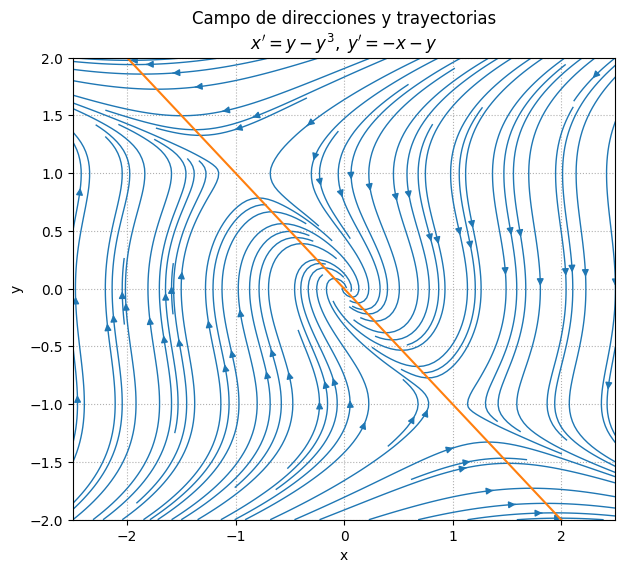

In [10]:
# Retrato de fases para: x' = y - y^3, y' = -x - y
import numpy as np
import matplotlib.pyplot as plt

# --- Definición del campo vectorial ---
def f(x, y):
    return y - y**3          # x' = y - y^3

def g(x, y):
    return -x - y            # y' = -x - y

# --- Parámetros del plano (ajústalos si quieres) ---
x_min, x_max = -2.5, 2.5
y_min, y_max = -2.0, 2.0
nx, ny = 25, 25              # densidad de la malla para el campo

# --- Malla ---
X, Y = np.meshgrid(
    np.linspace(x_min, x_max, nx),
    np.linspace(y_min, y_max, ny)
)

# --- Campo y normalización para flechas más legibles ---
U = f(X, Y)
V = g(X, Y)
speed = np.hypot(U, V)
speed[speed == 0] = 1.0      # evita división por cero
Un = U / speed
Vn = V / speed

# --- Semillas para las trayectorias (streamlines) ---
seed_x = np.linspace(x_min, x_max, 12)
seed_y = np.linspace(y_min, y_max, 9)
seed_points = np.array(np.meshgrid(seed_x, seed_y)).reshape(2, -1).T

# --- Gráfica ---
plt.figure(figsize=(7, 6))


# Trayectorias (líneas de flujo)
plt.streamplot(
    np.linspace(x_min, x_max, nx),
    np.linspace(y_min, y_max, ny),
    U, V,
    start_points=seed_points,
    density=3.0,
    linewidth=1.0,
    arrowsize=1.0,
    integration_direction='both'
)

# --- Nulclinas ---
# y - y^3 = 0  -> y = 0, ±1
# -x - y = 0   -> x = -y
xs = np.linspace(x_min, x_max, 400)
plt.plot(xs, -xs)            # recta x = -y


# --- Estética ---
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Campo de direcciones y trayectorias\n$x' = y - y^3,\\; y' = -x - y$")
plt.grid(True, linestyle=":")

plt.show()
